In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Load data
doc_level_path = '/data/home/xiong/data/Fund/CSR/Tractions/output/df_aiv.csv'
df = pd.read_csv(doc_level_path)
print(len(df))

1177


In [3]:
df.head()

,Print ISBN,filename_staff,text_staff,filename_buff,text_buff,text_sa,paragraphs_sa,paragraphs_bu,paragraphs_sr,paragraphs_av,...,buff_verified,staff_verified,"Extract text after "":""",Full Title,Subtitle,Title,Primary Country Code,Year from title,Publication Date,has_buff
0,9781513556642,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...","['25. Since the global financial crisis, Namib...",['My authorities appreciated the candid and pr...,"['1. Namibia is a small, upper middle-income c...",['9. The authorities share staff’s concerns an...,...,True,True,2015 Article IV Consultation-Press Release; S...,Namibia: 2015 Article IV Consultation-Press Re...,2015 Article IV Consultation-Press Release; St...,Namibia,NAM,2015.0,10/01/2015,1.0
1,9781475531671,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",NaN,NaN,"<html><body><sec id=""A01lev1sec5"">\n<title>Sta...",['34. The Uruguayan economy is decelerating gr...,NaN,['1. Uruguay’s economy performed strongly over...,['12. The authorities broadly agreed with staf...,...,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9781475586961,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['31. The Bulgarian economy and financial syst...,['The Bulgarian authorities highly appreciate ...,['1. Bulgaria’s reputation for macro-financial...,['9. The authorities broadly agreed with staff...,...,True,True,2015 Article IV Consultation-Staff Report; Pr...,Bulgaria: 2015 Article IV Consultation-Staff R...,2015 Article IV Consultation-Staff Report; Pre...,Bulgaria,BGR,2015.0,05/13/2015,1.0
3,9781513582290,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec3"">\n<title>Sta...",['30. The Norwegian economy has so far seen li...,"['On behalf of my Norwegian authorities, I wou...",['1. A sharp oil price drop materialized towar...,['12. The authorities generally agreed with th...,...,True,True,2015 Article IV Consultation - Press Release;...,Norway: 2015 Article IV Consultation - Press R...,2015 Article IV Consultation - Press Release; ...,Norway,NOR,2015.0,09/09/2015,1.0
4,9781513542218,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['35. The Angolan economy has been severely af...,['Angola has witnessed substantial improvement...,['1. Angola is a post-conflict country—decades...,['17. The authorities broadly agreed with staf...,...,True,True,2015 Article IV Consultation-Press Release; S...,Angola: 2015 Article IV Consultation-Press Rel...,2015 Article IV Consultation-Press Release; St...,Angola,AGO,2015.0,11/03/2015,1.0


In [13]:
# Filter for 2015-2023 and valid years
df = df[df['Year from title'].notna()]
df['year'] = df['Year from title'].astype(int)
df = df[(df['year'] >= 2015) & (df['year'] <= 2023)]

In [ ]:
# Define income groups based on IMF/World Bank classification
# AE = Advanced Economies, EM = Emerging Markets, UC = Upper-middle + Low income countries
ae_countries = ['USA', 'GBR', 'DEU', 'FRA', 'JPN', 'CAN', 'ITA', 'ESP', 'AUS', 'NLD', 
                'BEL', 'SWE', 'CHE', 'NOR', 'DNK', 'AUT', 'FIN', 'IRL', 'NZL', 'SGP',
                'HKG', 'ISR', 'KOR', 'PRT', 'GRC', 'CZE', 'SVK', 'SVN', 'EST', 'LVA',
                'LTU', 'CYP', 'MLT', 'ISL', 'LUX']

em_countries = ['CHN', 'IND', 'BRA', 'RUS', 'MEX', 'IDN', 'TUR', 'SAU', 'ARG', 'ZAF',
                'THA', 'MYS', 'PHL', 'POL', 'EGY', 'PAK', 'VNM', 'BGD', 'NGA', 'IRQ',
                'COL', 'CHL', 'ROU', 'PER', 'UKR', 'MAR', 'KAZ', 'QAT', 'ARE', 'KWT',
                'HUN', 'DZA', 'OMN', 'HRV', 'BLR', 'BGR']

def classify_income_group(code):
    if pd.isna(code):
        return 'Unknown'
    if code in ae_countries:
        return 'AE'
    elif code in em_countries:
        return 'EM'
    else:
        return 'LC'

df['income_group'] = df['Primary Country Code'].apply(classify_income_group)
counts = df.groupby(['year', 'income_group']).size().unstack(fill_value=0)

# # Ensure all three groups exist
# for group in ['AE', 'EM', 'LC']:
#     if group not in counts.columns:
#         counts[group] = 0

# Reorder columns
counts = counts[['AE', 'EM', 'LC']]

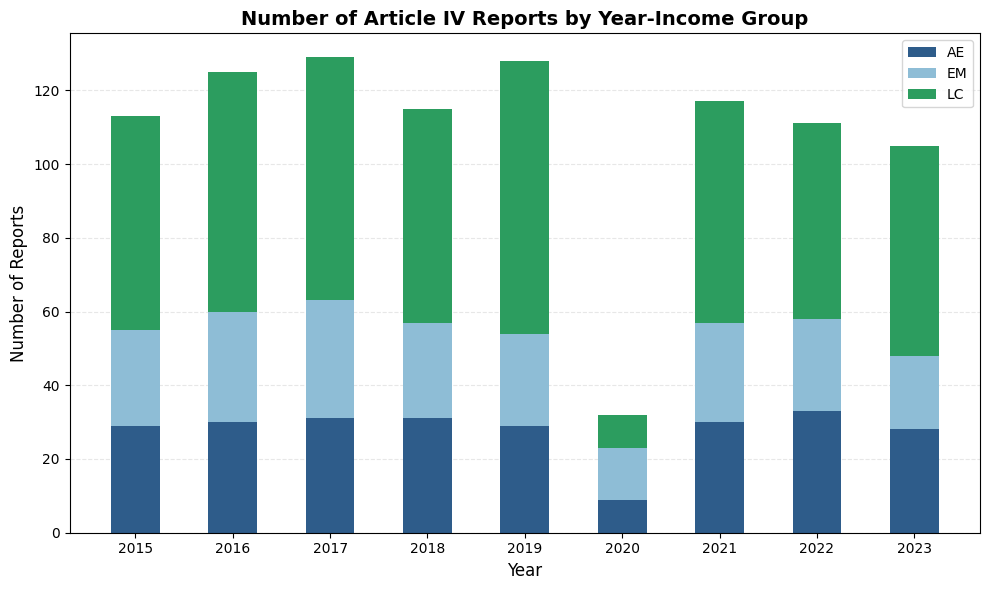


Total reports by income group:
income_group
AE    250
EM    225
LC    500
dtype: int64

Total reports: 975

Reports by year:
year
2015    113
2016    125
2017    129
2018    115
2019    128
2020     32
2021    117
2022    111
2023    105
dtype: int64


In [12]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
years = counts.index
width = 0.5
# Colors matching the chart
colors = {'AE': '#2E5C8A', 'EM': '#8EBDD6', 'LC': '#2C9D5F'}
# Create stacked bars
bottom = np.zeros(len(years))
for group in ['AE', 'EM', 'LC']:
    ax.bar(years, counts[group], width, label=group, 
           bottom=bottom, color=colors[group])
    bottom += counts[group].values

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Reports', fontsize=12)
ax.set_title('Number of Article IV Reports by Year-Income Group', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal reports by income group:")
print(counts.sum())
print(f"\nTotal reports: {counts.sum().sum()}")
print(f"\nReports by year:")
print(counts.sum(axis=1))